In [2]:
!pip install sentence-transformers spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [3]:
# Clean install numpy and gensim with compatible versions
!pip uninstall -y numpy gensim
!pip install numpy==1.26.4 gensim==4.3.3 --no-cache-dir --force-reinstall

# Restart the runtime after this step manually!


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 65.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 288.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 288.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 226.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 225.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: smart-open
    Found existing installation: smart-open 7.1.0
    Uninstalling smart-open-7.1.0:
      Successfully uninstalled smart-open-7.1.0
  Attempting 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import gensim.downloader as api
from sentence_transformers import SentenceTransformer
import spacy
from scipy.stats import pearsonr

In [2]:
# Load and preprocess the dataset
file_path = "ldt word item analysis.xlsx"
df = pd.read_excel(file_path, sheet_name='ldt word item analysis')
df


,target,short_1st_rel,short_1st_rel_err,short_1st_un,short_1st_un_err,short_other_rel,short_other_rel_err,short_other_un,short_other_un_err,long_1st_rel,...,otherassoc_bas,otherassoc_fanout,otherassoc_rank,otherassoc_lsa,otherassoc_length,otherassoc_loghal,otherassoc_logsubtitle,otherassoc_ortho,otherassoc_elp,otherassoc_relation
0,abandon,1.247228,0.096774,1.305780,0.093750,0.634933,0.031250,0.029621,0.129032,0.194348,...,NaN,14,6,0.01,6.0,6.36,1.79,0.0,655.85,unclassifed
1,ability,0.379233,0.000000,0.315568,0.062500,0.242856,0.031250,0.076921,0.062500,-0.049116,...,0.0,13,4,0.31,5.0,11.78,4.05,8.0,686.57,unclassifed
2,abnormal,0.443351,0.032258,0.788199,0.062500,0.821015,0.125000,0.999505,0.060606,0.385538,...,0.0,15,3,0.07,9.0,7.66,2.11,0.0,655.77,synonym
3,above,0.165210,0.032258,-0.027777,0.000000,-0.398669,0.000000,-0.144946,0.000000,-0.415244,...,0.0,11,5,0.15,8.0,7.88,3.56,0.0,587.67,unclassifed
4,abuse,-0.035206,0.032258,0.405268,0.000000,-0.235285,0.062500,0.250415,0.064516,-0.040059,...,0.0,13,6,0.15,7.0,8.92,2.91,0.0,684.23,synonym
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1656,yours,-0.220784,0.000000,-0.255903,0.032258,0.257826,0.093750,0.264784,0.000000,-0.300064,...,0.0,20,6,0.17,5.0,9.90,3.73,2.0,587.50,unclassified
1657,zero,-0.170363,0.000000,-0.164294,0.062500,-0.085825,0.031250,-0.238616,0.032258,-0.299975,...,0.0,12,2,0.16,4.0,11.97,3.75,8.0,556.14,unclassified
1658,zit,0.753653,0.062500,1.088687,0.250000,0.686606,0.250000,1.124949,0.312500,0.526674,...,0.0,10,10,NaN,6.0,6.74,2.12,2.0,685.12,unclassified
1659,zone,-0.051306,0.064516,0.001369,0.031250,0.443029,0.064516,0.241834,0.031250,0.075249,...,0.0,20,6,0.11,9.0,8.69,2.59,0.0,619.75,fpa


Below code is calculating the correlation between priming effect and cosine similarity between prime and target words. We are comparing two models Word2Vec and SBERT

**Note: We took reference from the paper "Hutchison et al. (2013)" to calculate priming effect, where priming effect was defined as "Priming = RT_unrelated – RT_related"**

In [ ]:
df.columns

Index(['target', 'short_1st_rel', 'short_1st_rel_err', 'short_1st_un',
       'short_1st_un_err', 'short_other_rel', 'short_other_rel_err',
       'short_other_un', 'short_other_un_err', 'long_1st_rel',
       'long_1st_rel_err', 'long_1st_un', 'long_1st_un_err', 'long_other_rel',
       'long_other_rel_err', 'long_other_un', 'long_other_un_err',
       'short_first_priming', 'short_other_priming', 'long_first_priming',
       'long_other_priming', 'first_priming_overall', 'other_priming_overall',
       'VAR00003', 'VAR00001', 'prime_1st_assoc', 'target_length',
       'target_loghal', 'target_subtitle', 'target_logsubtitle',
       'target_ortho', 'target_pos', 'target_elprt', 'target_elpz',
       'target_elpacc', 'target_fanin', 'firstassoc_logsubtitle',
       'firstassoc_length', 'firstassoc_loghal', 'firstassoc_ortho',
       'firstassoc_elp', 'firstassoc_relationtype', 'firstassoc_fas',
       'firstassoc_bas', 'firstassoc_fanout', 'firstassoc_fanin',
       'firstassoc_lsa', '

Loading Word2Vec (Google News)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loading SBERT...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading spaCy...

✅ Word2Vec Valid Pairs: 1657 / 1661
📊 Correlation (Word2Vec Similarity vs Priming Effect): 0.1191
📊 Correlation (SBERT Similarity vs Priming Effect): 0.0861

🔠 POS Sample:
       prime prime_POS  target target_POS
1126   WRITE     PROPN   print       NOUN
1175  DENIAL     PROPN  refuse       VERB
1343  REGRET     PROPN   sorry        ADJ
1283     GUN     PROPN   shoot       VERB
1588  DISHES      NOUN    wash       NOUN


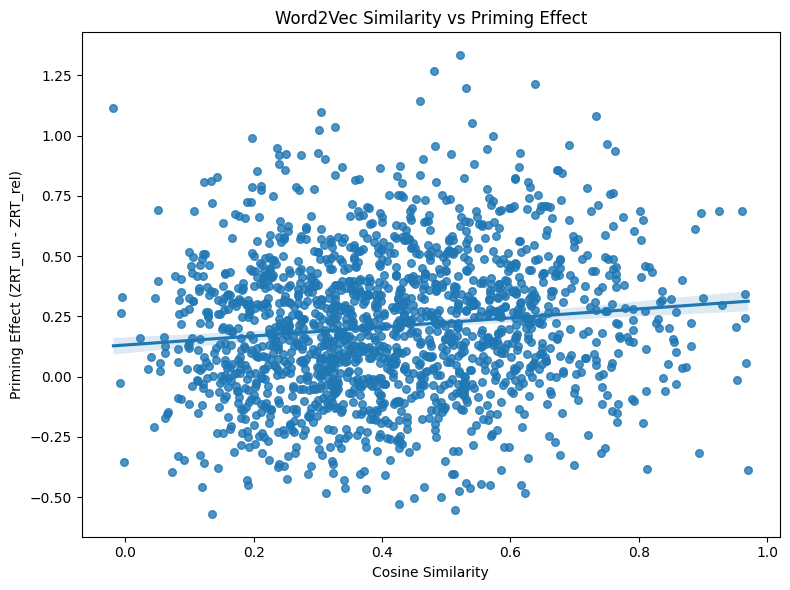

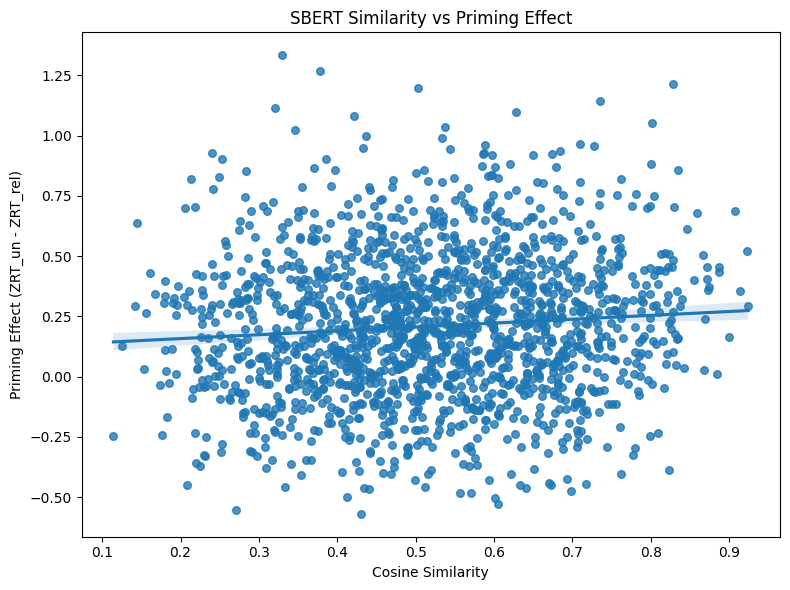

In [ ]:
# Select relevant columns and rename
df = df[['prime_1st_assoc', 'target', 'short_1st_rel', 'short_1st_un']].dropna()
df = df.rename(columns={'prime_1st_assoc': 'prime'})

# Compute the priming effect (positive means faster RT in related condition)
df['priming_effect'] = df['short_1st_un'] - df['short_1st_rel']

# Load models
print("Loading Word2Vec (Google News)...")
w2v_model = api.load("word2vec-google-news-300")
print("Loading SBERT...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Loading spaCy...")
nlp = spacy.load("en_core_web_sm")

# POS tagging
df['prime_POS'] = df['prime'].apply(lambda w: nlp(w)[0].pos_ if nlp(w) else "X")
df['target_POS'] = df['target'].apply(lambda w: nlp(w)[0].pos_ if nlp(w) else "X")

# -- SBERT Cosine Similarity --
df['sbert_similarity'] = df.apply(
    lambda row: cosine_similarity(
        [sbert_model.encode(str(row['prime']))],
        [sbert_model.encode(str(row['target']))]
    )[0][0], axis=1)

# -- Word2Vec Similarity (lowercased, filter valid) --
def valid_w2v(word):
    return word.lower() in w2v_model

df['w2v_valid'] = df.apply(lambda row: valid_w2v(row['prime']) and valid_w2v(row['target']), axis=1)
df_w2v = df[df['w2v_valid']].copy()

# Compute Word2Vec cosine similarity
df_w2v['w2v_similarity'] = [
    cosine_similarity(
        [w2v_model[row['prime'].lower()]],
        [w2v_model[row['target'].lower()]]
    )[0][0]
    for _, row in df_w2v.iterrows()
]

# Correlations
cor_w2v = df_w2v['w2v_similarity'].corr(df_w2v['priming_effect'])
cor_sbert = df['sbert_similarity'].corr(df['priming_effect'])

# Plotting function
def plot_similarity(dataframe, sim_col, title):
    plt.figure(figsize=(8, 6))
    sns.regplot(data=dataframe, x=sim_col, y='priming_effect', scatter_kws={"s": 30})
    plt.title(title)
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Priming Effect (ZRT_un - ZRT_rel)')
    plt.tight_layout()
    plt.show()

# Summary
print(f"\nWord2Vec Valid Pairs: {len(df_w2v)} / {len(df)}")
print(f"Correlation (Word2Vec Similarity vs Priming Effect): {cor_w2v:.4f}")
print(f"Correlation (SBERT Similarity vs Priming Effect): {cor_sbert:.4f}")
print("\nPOS Sample:")
print(df[['prime', 'prime_POS', 'target', 'target_POS']].sample(5))

# Plot results
plot_similarity(df_w2v, 'w2v_similarity', 'Word2Vec Similarity vs Priming Effect')
plot_similarity(df, 'sbert_similarity', 'SBERT Similarity vs Priming Effect')

In [ ]:
from scipy.stats import pearsonr

# Example:
r_w2v, p_w2v = pearsonr(df_w2v['w2v_similarity'], df_w2v['priming_effect'])
r_sbert, p_sbert = pearsonr(df['sbert_similarity'], df['priming_effect'])

print(f"Word2Vec: r = {r_w2v:.4f}, p = {p_w2v:.4e}")
print(f"SBERT:    r = {r_sbert:.4f}, p = {p_sbert:.4e}")


Word2Vec: r = 0.1191, p = 1.1707e-06
SBERT:    r = 0.0861, p = 4.4589e-04


**Below is the updated code on the basis of feedback given during presentation**

Here, We have calculated correlation between Related Similarity vs RT as well as between Unrelated Similarity vs RT

Loading Word2Vec (Google News)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loading SBERT...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Word2Vec:
Related Similarity vs RT: r = 0.0224, p = 3.6318e-01
Unrelated Similarity vs RT: r = -0.0034, p = 8.8987e-01

SBERT:
Related Similarity vs RT: r = -0.0848, p = 5.5784e-04
Unrelated Similarity vs RT: r = -0.1296, p = 1.2555e-07


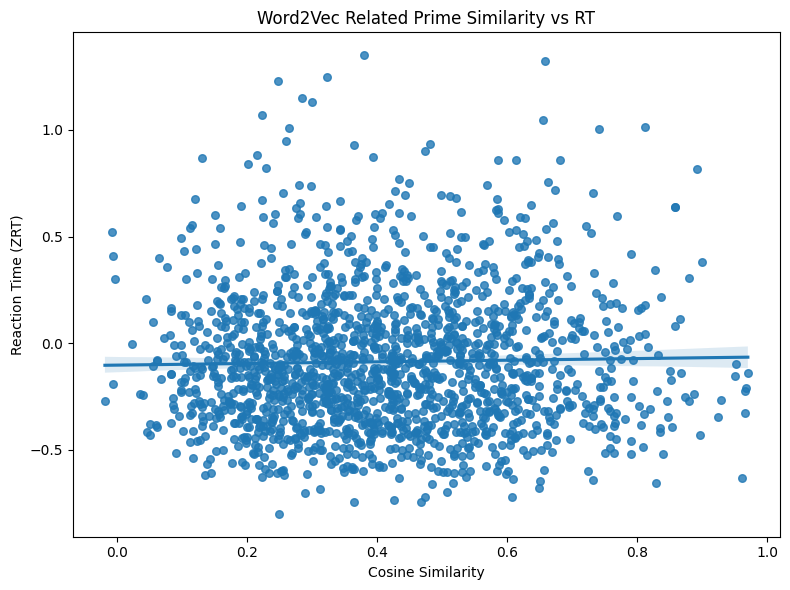

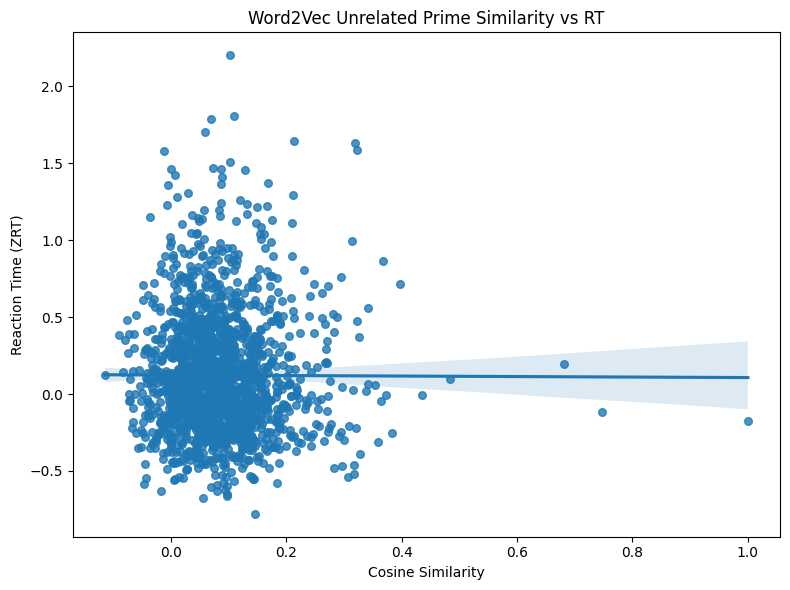

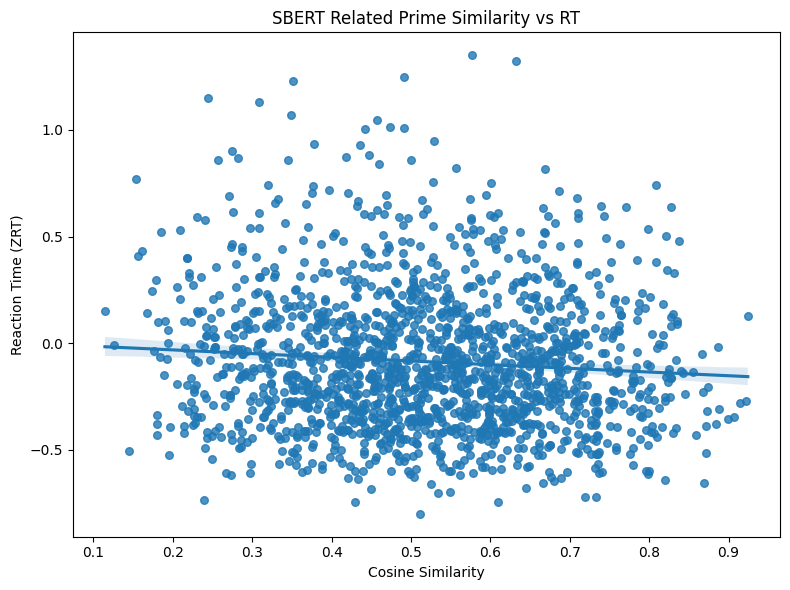

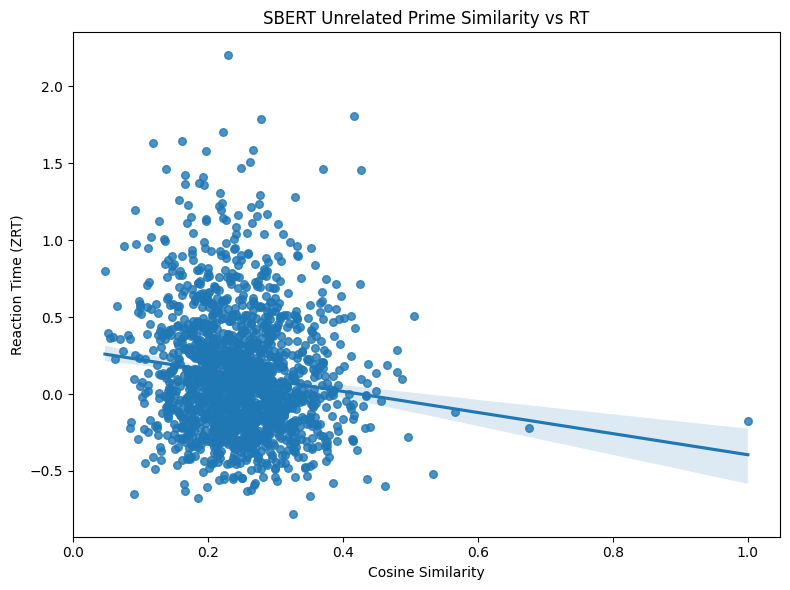

In [4]:
# Keep only necessary columns
df = df[['prime_1st_assoc', 'prime_1st_unrelated', 'target', 'short_1st_rel', 'short_1st_un']].dropna()

# Load models
print("Loading Word2Vec (Google News)...")
w2v_model = api.load("word2vec-google-news-300")
print("Loading SBERT...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# -- Cosine Similarity Functions --
def valid_w2v(word):
    return word.lower() in w2v_model

def get_w2v_vector(word):
    return w2v_model[word.lower()] if valid_w2v(word) else np.zeros(300)

def get_sbert_vector(word):
    return sbert_model.encode(str(word))

# -- Compute Similarities --
# Only keep rows where both primes and target exist in vocabulary
w2v_valid = df.apply(lambda row: valid_w2v(row['prime_1st_assoc']) and valid_w2v(row['prime_1st_unrelated']) and valid_w2v(row['target']), axis=1)
df_w2v = df[w2v_valid].copy()

# Related prime similarity
df_w2v['w2v_related_similarity'] = [
    cosine_similarity([get_w2v_vector(row['prime_1st_assoc'])], [get_w2v_vector(row['target'])])[0][0]
    for _, row in df_w2v.iterrows()
]

# Unrelated prime similarity
df_w2v['w2v_unrelated_similarity'] = [
    cosine_similarity([get_w2v_vector(row['prime_1st_unrelated'])], [get_w2v_vector(row['target'])])[0][0]
    for _, row in df_w2v.iterrows()
]

# SBERT Related similarity
df_w2v['sbert_related_similarity'] = [
    cosine_similarity([get_sbert_vector(row['prime_1st_assoc'])], [get_sbert_vector(row['target'])])[0][0]
    for _, row in df_w2v.iterrows()
]

# SBERT Unrelated similarity
df_w2v['sbert_unrelated_similarity'] = [
    cosine_similarity([get_sbert_vector(row['prime_1st_unrelated'])], [get_sbert_vector(row['target'])])[0][0]
    for _, row in df_w2v.iterrows()
]

# -- Correlation Analysis --
r_w2v_rel, p_w2v_rel = pearsonr(df_w2v['w2v_related_similarity'], df_w2v['short_1st_rel'])
r_w2v_unrel, p_w2v_unrel = pearsonr(df_w2v['w2v_unrelated_similarity'], df_w2v['short_1st_un'])

r_sbert_rel, p_sbert_rel = pearsonr(df_w2v['sbert_related_similarity'], df_w2v['short_1st_rel'])
r_sbert_unrel, p_sbert_unrel = pearsonr(df_w2v['sbert_unrelated_similarity'], df_w2v['short_1st_un'])

# -- Print Results --
print("\nWord2Vec:")
print(f"Related Similarity vs RT: r = {r_w2v_rel:.4f}, p = {p_w2v_rel:.4e}")
print(f"Unrelated Similarity vs RT: r = {r_w2v_unrel:.4f}, p = {p_w2v_unrel:.4e}")

print("\nSBERT:")
print(f"Related Similarity vs RT: r = {r_sbert_rel:.4f}, p = {p_sbert_rel:.4e}")
print(f"Unrelated Similarity vs RT: r = {r_sbert_unrel:.4f}, p = {p_sbert_unrel:.4e}")

# -- Plotting --
def plot_similarity(dataframe, sim_col, rt_col, title):
    plt.figure(figsize=(8, 6))
    sns.regplot(data=dataframe, x=sim_col, y=rt_col, scatter_kws={"s": 30})
    plt.title(title)
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Reaction Time (ZRT)')
    plt.tight_layout()
    plt.show()

# Related and Unrelated plots
plot_similarity(df_w2v, 'w2v_related_similarity', 'short_1st_rel', 'Word2Vec Related Prime Similarity vs RT')
plot_similarity(df_w2v, 'w2v_unrelated_similarity', 'short_1st_un', 'Word2Vec Unrelated Prime Similarity vs RT')

plot_similarity(df_w2v, 'sbert_related_similarity', 'short_1st_rel', 'SBERT Related Prime Similarity vs RT')
plot_similarity(df_w2v, 'sbert_unrelated_similarity', 'short_1st_un', 'SBERT Unrelated Prime Similarity vs RT')